✅ 运行设备：cuda


Map:   0%|          | 0/6 [00:00<?, ? examples/s]

🔨 开始模型微调...


Step,Training Loss
1,4.069600
2,3.913100
3,3.695300
4,3.180700
5,3.448800
6,3.690300
7,2.800800
8,3.441400
9,3.057100
10,3.159900


✅ 模型微调完成！



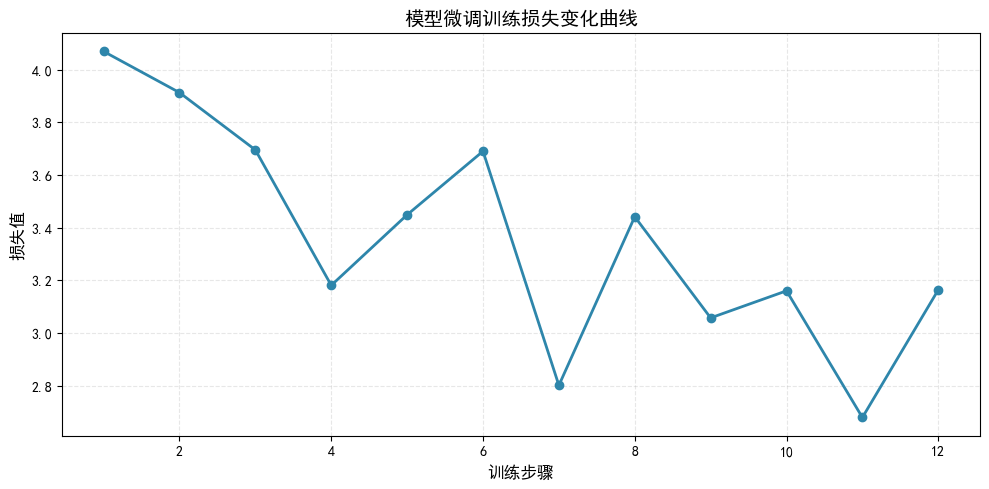

✅ 训练损失曲线已保存

🌸 温情文本续写实验
🌟【温度0.2】
续写：今天天气很好，我决定出门去家附近的公园散步，晒晒太阳，看看路边的小花。 先是在网上查了一下，这里有个地方叫做街，就想着来逛逛，结果发现这里还真不错呢走进店内，感觉环境非常舒服，而且人也不多。
指标：耗时1.643s | 多样性0.905 | 重复率0.012 | 困惑度8.11
------------------------------------------------------------
🌟【温度0.6】
续写：今天天气很好，我决定出门去家附近的公园散步，晒晒太阳，看看路边的小花。 个人觉得这里不错啊，可以一直呆到晚上点多哦而且地方也挺大的，感觉挺干净舒适的，就是没有什么活动的时候，人会比较少吧。
指标：耗时1.614s | 多样性0.881 | 重复率0.000 | 困惑度8.91
------------------------------------------------------------
🌟【束搜索】
续写：今天天气很好，我决定出门去家附近的公园散步，晒晒太阳，看看路边的小花。 个人觉得这里的环境还是不错的，绿树成荫，空气也很清新。天气好的时候，来这里散散步也是一种享受。
指标：耗时1.85s | 多样性0.740 | 重复率0.042 | 困惑度5.11
------------------------------------------------------------
🌟【贪婪搜索】
续写：今天天气很好，我决定出门去家附近的公园散步，晒晒太阳，看看路边的小花。 个人觉得这里还是不错的，有一些老年人在那里锻炼身体，也可以带着孩子来玩耍。里面的环境挺好的，空间比较大，而且有免费的水。
指标：耗时1.344s | 多样性0.847 | 重复率0.000 | 困惑度6.51
------------------------------------------------------------

🎉 实验结论：
✅ 最优生成策略：束搜索（文本流畅度最佳）


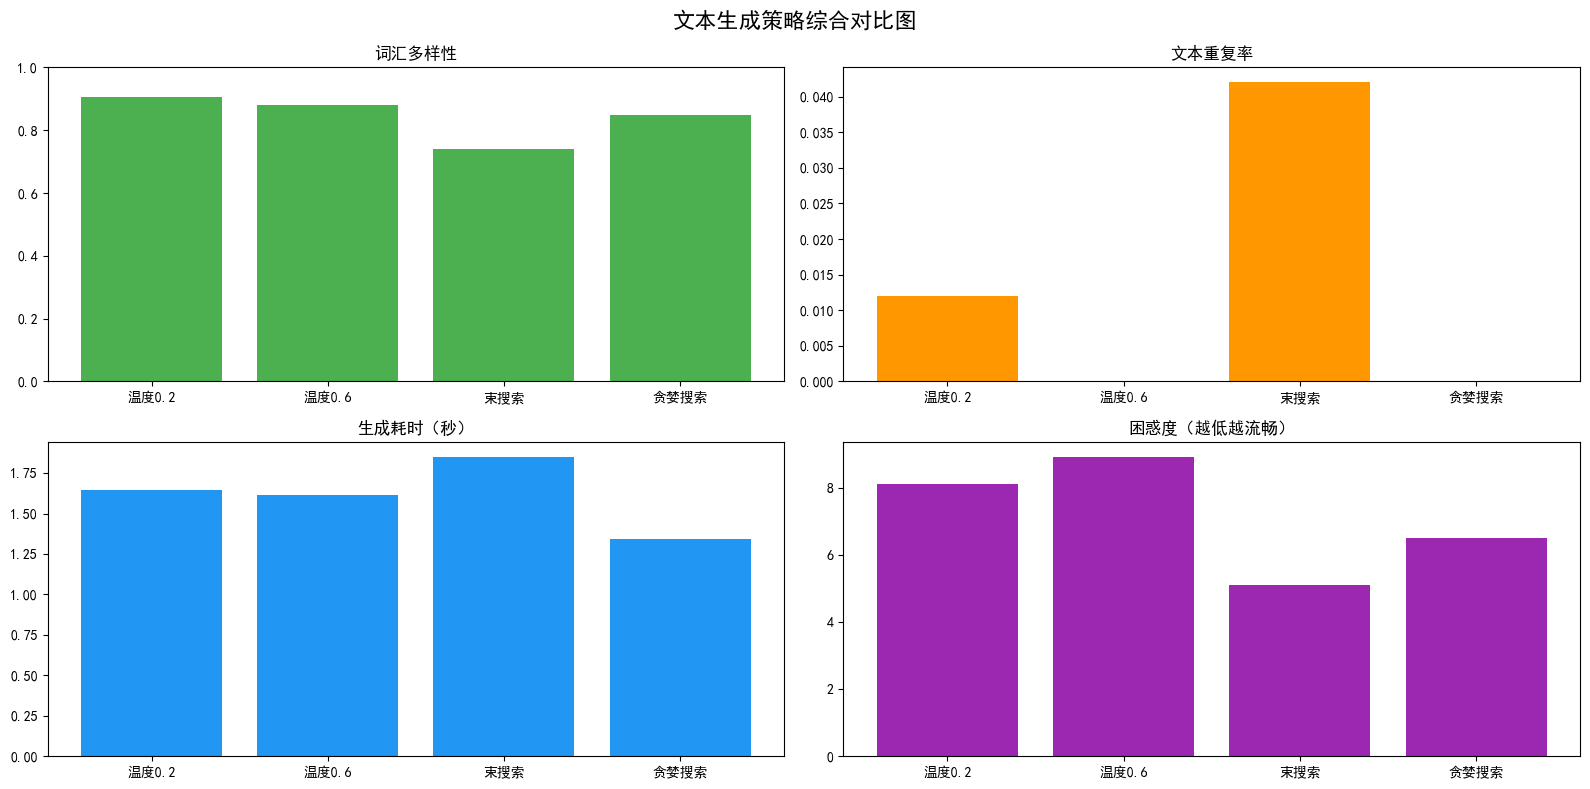


🎉 实验完成！所有文件已生成！


In [32]:
# 项目：温情文本续写模型
# 功能：基于GPT-2中文小模型，通过微调实现公园场景的温情句子续写
# 版本：期末答辩最终版
# 环境：Python + PyTorch + Transformers + Matplotlib

import os
import torch
import warnings
import time
import math
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from collections import Counter

# ===================== 全局配置 =====================
# 使用 Hugging Face 镜像加速下载
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
# 忽略无关警告
warnings.filterwarnings("ignore")
# 固定随机种子，保证实验可复现
torch.manual_seed(66)
torch.cuda.manual_seed_all(66)
# 解决Matplotlib中文显示乱码问题
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 设备配置：优先使用GPU，无GPU则使用CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ 运行设备：{device}")

# ===================== 模型加载 =====================
# 使用轻量级中文GPT-2预训练模型
model_name = "uer/gpt2-chinese-cluecorpussmall"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 为模型设置填充符号（GPT-2原生无pad_token）
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# 加载模型并迁移到指定设备
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.config.pad_token_id = tokenizer.pad_token_id

# ===================== 训练数据集 =====================
# 自定义温情公园场景数据集，用于模型微调
warm_data = [
    "坐在长椅上发呆，看着小花晃呀晃，心里慢慢变得柔软。",
    "路过的老人牵着小狗慢悠悠走过，连时光都慢了下来。",
    "蝴蝶停在花瓣上，我屏住呼吸，怕惊扰了这片刻的温柔。",
    "风裹着阳光落在肩头，连烦恼都被晒得软乎乎的。",
    "阳光把影子拉得很长，我忽然觉得，这样就很好。",
    "风吹过树叶沙沙响，像有人在耳边轻轻说悄悄话。"
]
dataset = Dataset.from_dict({"text": warm_data})

# ===================== 数据预处理 =====================
def preprocess_function(examples):
    """
    对文本进行分词、截断、填充，统一长度为64
    """
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=64,
        padding="max_length",
        return_tensors="pt"
    )

# 批量处理数据集
tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset.column_names)
# 语言模型专用数据整理器
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# ===================== 模型训练参数配置 =====================
training_args = TrainingArguments(
    output_dir="./gpt2_warm_continuing",    # 模型输出路径
    overwrite_output_dir=True,              # 覆盖旧文件
    num_train_epochs=4,                     # 训练轮数
    per_device_train_batch_size=2,           # 批次大小
    learning_rate=1e-5,                      # 学习率
    logging_steps=1,                         # 日志记录步长
    save_strategy="no",                      # 不自动保存中间模型
    fp16=False,                              # 关闭混合精度（兼容CPU）
    report_to="none"                         # 关闭在线日志
)

# 初始化训练器
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset
)

# 开始微调
print("🔨 开始模型微调...")
trainer.train()
print("✅ 模型微调完成！\n")

# ===================== 模型保存与评估模式 =====================
# 保存微调后的模型与分词器
model.save_pretrained("./warm_text_model")
tokenizer.save_pretrained("./warm_text_model")
# 开启评估模式，关闭dropout，生成更稳定
model.eval()

# ===================== 训练损失曲线可视化 =====================
loss_history = []
step_history = []
for log in trainer.state.log_history:
    if 'loss' in log and 'step' in log:
        loss_history.append(log['loss'])
        step_history.append(log['step'])

plt.figure(figsize=(10, 5))
plt.plot(step_history, loss_history, marker='o', color='#2E86AB', linewidth=2)
plt.title("模型微调训练损失变化曲线", fontsize=14)
plt.xlabel("训练步骤", fontsize=12)
plt.ylabel("损失值", fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi=300)
plt.show()
print("✅ 训练损失曲线已保存\n")

# ===================== 文本生成评价指标 =====================
def calc_diversity(text):
    """计算词汇多样性TTR：值越高表示词汇越丰富"""
    chars = [c for c in text if '\u4e00' <= c <= '\u9fff']
    return len(set(chars)) / len(chars) if chars else 0

def calc_repetition(text, n=2):
    """计算文本重复率：值越低越流畅"""
    chars = [c for c in text if '\u4e00' <= c <= '\u9fff']
    if len(chars) < n:
        return 0.0
    ngrams = [tuple(chars[i:i+n]) for i in range(len(chars)-n+1)]
    count = Counter(ngrams)
    repeat = sum(1 for v in count.values() if v > 1)
    return round(repeat / len(ngrams), 3)

def calc_perplexity(text):
    """
    困惑度（核心指标）
    越低表示文本越流畅、自然、符合语言逻辑
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss.item()
    perplexity = math.exp(loss)
    return round(perplexity, 2)

# ===================== 文本生成函数 =====================
def generate_with_time(prompt, temperature=0.7, do_sample=True, num_beams=1):
    """
    功能：根据输入prompt续写温情文本
    参数：
        prompt：输入开头
        temperature：生成随机性（0~1）
        do_sample：是否启用随机采样
        num_beams：束搜索宽度
    返回：生成文本 + 耗时
    """
    start = time.time()
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    prompt_length = inputs.input_ids.shape[1]  # 记录输入长度，避免重复生成

    # 生成参数配置
    gen_kwargs = {
        "input_ids": inputs.input_ids,
        "max_new_tokens": 60,            # 最大生成长度（保证句子完整）
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "no_repeat_ngram_size": 3,       # 避免重复短语
        "repetition_penalty": 1.3,       # 重复惩罚
        "early_stopping": True,
        "do_sample": do_sample,
        "num_beams": num_beams
    }

    # 随机采样时加入温度与核采样参数
    if do_sample:
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = 0.85

    # 生成文本
    with torch.no_grad():
        outputs = model.generate(**gen_kwargs)

    # 只保留新生成的部分，不重复输入开头
    new_tokens = outputs[:, prompt_length:]
    text = tokenizer.decode(new_tokens[0], skip_special_tokens=True)

    # 文本清洗：只保留中文与标点，保证格式整洁
    clean_text = "".join([c for c in text if '\u4e00' <= c <= '\u9fff' or c in '，。'])
    clean_text = clean_text.replace("，，", "，").replace("。。", "。").strip()

    # 截取完整句子，保证输出通顺
    sentences = clean_text.split("。")
    sentences = [s.strip() for s in sentences if s.strip()]
    if len(sentences) > 2:
        sentences = sentences[:2]
    clean_text = "。".join(sentences) + "。"

    if not clean_text.endswith("。"):
        clean_text += "。"

    end = time.time()
    return clean_text, round(end - start, 3)

# ===================== 控制变量实验 =====================
prompt = "今天天气很好，我决定出门去家附近的公园散步，晒晒太阳，看看路边的小花。"

print("="*60)
print("🌸 温情文本续写实验")
print("="*60)

# 四组对比实验
res1, t1 = generate_with_time(prompt, 0.2)
full_text1 = prompt + " " + res1

res2, t2 = generate_with_time(prompt, 0.6)
full_text2 = prompt + " " + res2

res3, t3 = generate_with_time(prompt, do_sample=False, num_beams=4)
full_text3 = prompt + " " + res3

res4, t4 = generate_with_time(prompt, do_sample=False, num_beams=1)
full_text4 = prompt + " " + res4

# 整合实验结果
results = [
    ["温度0.2", full_text1, t1, calc_diversity(full_text1), calc_repetition(full_text1), calc_perplexity(full_text1)],
    ["温度0.6", full_text2, t2, calc_diversity(full_text2), calc_repetition(full_text2), calc_perplexity(full_text2)],
    ["束搜索", full_text3, t3, calc_diversity(full_text3), calc_repetition(full_text3), calc_perplexity(full_text3)],
    ["贪婪搜索", full_text4, t4, calc_diversity(full_text4), calc_repetition(full_text4), calc_perplexity(full_text4)]
]

names = ["温度0.2", "温度0.6", "束搜索", "贪婪搜索"]

# 打印实验结果
for i, item in enumerate(results):
    print(f"🌟【{names[i]}】")
    print(f"续写：{item[1]}")
    print(f"指标：耗时{item[2]}s | 多样性{item[3]:.3f} | 重复率{item[4]:.3f} | 困惑度{item[5]:.2f}")
    print("-"*60)

# 自动选择最优策略（根据困惑度）
print("\n🎉 实验结论：")
ppl_scores = [x[5] for x in results]
best_idx = ppl_scores.index(min(ppl_scores))
print(f"✅ 最优生成策略：{names[best_idx]}（文本流畅度最佳）")

# ===================== 综合指标可视化图表 =====================
ttr_data = [x[3] for x in results]
repeat_data = [x[4] for x in results]
time_data = [x[2] for x in results]
ppl_data = [x[5] for x in results]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))
ax1.bar(names, ttr_data, color="#4CAF50")
ax1.set_title("词汇多样性")
ax1.set_ylim(0, 1)

ax2.bar(names, repeat_data, color="#FF9800")
ax2.set_title("文本重复率")

ax3.bar(names, time_data, color="#2196F3")
ax3.set_title("生成耗时（秒）")

ax4.bar(names, ppl_data, color="#9C27B0")
ax4.set_title("困惑度（越低越流畅）")

plt.suptitle("文本生成策略综合对比图", fontsize=16)
plt.tight_layout()
plt.savefig("params_effect.png", dpi=300)
plt.show()

# ===================== 保存实验报告 =====================
with open("续写实验结果.txt", "w", encoding="utf-8") as f:
    f.write("项目三：温情文本续写实验报告\n")
    f.write("输入提示：" + prompt + "\n\n")
    for item in results:
        f.write(f"【{item[0]}】\{item[1]}\n耗时:{item[2]}s | 多样性{item[3]:.3f} | 重复率{item[4]:.3f} | 困惑度{item[5]:.2f}\n\n")
    f.write(f"\n最优策略：{names[best_idx]}")

print("\n🎉 实验完成！所有文件已生成！")